# GNN-Based Spatial Clustering for Visium Data

This notebook demonstrates Baseline 2 from the project description: a graph autoencoder that learns spatial embeddings from Visium data.

**Baseline approach:** GCN encoder → latent embedding → linear decoder reconstructs original features → KMeans clusters on the latent embedding.

**Applicable to Direction A** (single-modality biomarker discovery). The same approach can be applied to MSI data or adapted for the other two datasets.

**Prerequisites:** scanpy, squidpy, torch, torch_geometric, scikit-learn

In [ ]:
import os
import scanpy as sc
import squidpy as sq
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
torch.manual_seed(42)
np.random.seed(42)

## 1. Load and Preprocess Data

**IMPORTANT:** Update the data path below. We use one sample from the SMA brain dataset (the same sample featured in the MAGPIE tutorial) as our running example.

In [2]:
# =============================================================
# UPDATE THIS PATH to point to one sample's visium directory
# =============================================================
SAMPLE_VISIUM = "../data_download/magpie_inputs/sma_vicari_brain/mouse_V11L12-038_D1/visium"

adata = sc.read_visium(SAMPLE_VISIUM)
adata.var_names_make_unique()
print(f'Loaded: {adata.shape[0]} spots, {adata.shape[1]} genes')

Loaded: 2913 spots, 32285 genes


In [3]:
# Standard preprocessing
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# NOTE: HVG selection reduces features for this baseline demo. You can adjust this:
#   - n_top_genes=2000 (default) — fast, good for clustering baseline
#   - n_top_genes=3000-5000 — broader coverage, may capture more disease-relevant genes
#   - Skip HVG entirely and use all genes — preserves all signals but higher dimensionality
#     (consider PCA to reduce dimensions before feeding into GNN)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat')
adata = adata[:, adata.var.highly_variable].copy()
print(f'After preprocessing: {adata.shape[0]} spots, {adata.shape[1]} genes')

After preprocessing: 2907 spots, 2000 genes


## 2. Build Spatial Graph

Treat each Visium spot as a node and connect it to its `n_neighs` spatial neighbors. This gives us a graph that encodes the tissue's spatial structure. `n_neighs=6` is a natural choice for Visium's hexagonal lattice, but treat it as a hyperparameter.

In [4]:
sq.gr.spatial_neighbors(adata, n_neighs=6, coord_type='generic')

adj_matrix = adata.obsp['spatial_connectivities']
edge_index = torch.tensor(np.array(adj_matrix.nonzero()), dtype=torch.long)

X_array = adata.X.toarray() if scipy.sparse.issparse(adata.X) else np.asarray(adata.X)
x = torch.tensor(X_array, dtype=torch.float)

graph_data = Data(x=x, edge_index=edge_index).to(device)

print(f'Graph: {x.shape[0]} nodes, {edge_index.shape[1]} edges')
print(f'Node features: {x.shape[1]} dimensions')
print(f'Average degree: {edge_index.shape[1] / x.shape[0]:.1f}')

Graph: 2907 nodes, 17442 edges
Node features: 2000 dimensions
Average degree: 6.0


## 3. Define Graph Autoencoder Model

Simple graph autoencoder: GCN encoder → low-dimensional latent → linear decoder reconstructs the original features. Training optimizes MSE reconstruction loss.

**Ideas to improve this baseline:**
- Replace `GCNConv` with `GATConv` (attention-based) or `SAGEConv` (GraphSAGE)
- Add contrastive loss (InfoNCE) with negative sampling
- Use a variational graph autoencoder (VGAE)
- Deeper architectures with residual connections
- Multi-sample training: treat each sample as a subgraph

In [5]:
class GraphAutoencoder(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, latent_channels=32):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = GCNConv(hidden_channels, latent_channels)
        self.decoder = nn.Linear(latent_channels, in_channels)
    
    def encode(self, x, edge_index):
        h = F.relu(self.bn1(self.conv1(x, edge_index)))
        h = F.dropout(h, p=0.3, training=self.training)
        return self.conv2(h, edge_index)
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x, edge_index):
        z = self.encode(x, edge_index)
        return z, self.decode(z)

## 4. Training

Epoch 50/300, Loss: 0.1407
Epoch 100/300, Loss: 0.1129
Epoch 150/300, Loss: 0.0982
Epoch 200/300, Loss: 0.0906
Epoch 250/300, Loss: 0.0878
Epoch 300/300, Loss: 0.0859


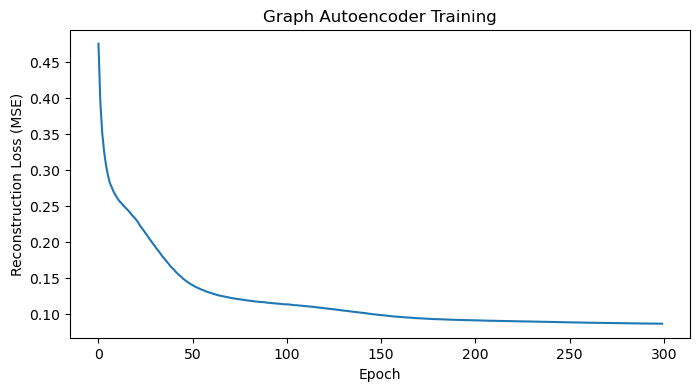

In [6]:
model = GraphAutoencoder(
    in_channels=x.shape[1],
    hidden_channels=128,
    latent_channels=32,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
n_epochs = 300

losses = []
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    _, x_recon = model(graph_data.x, graph_data.edge_index)
    loss = F.mse_loss(x_recon, graph_data.x)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}')

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Epoch'); plt.ylabel('Reconstruction Loss (MSE)')
plt.title('Graph Autoencoder Training')
plt.show()

## 5. Clustering and Visualization

Extract embeddings, cluster with KMeans, and compare against vanilla Leiden clustering on the original expression space.

In [7]:
model.eval()
with torch.no_grad():
    z, _ = model(graph_data.x, graph_data.edge_index)
    embeddings = z.cpu().numpy()

print(f'Embedding shape: {embeddings.shape}')

adata.obsm['X_gnn'] = embeddings

n_clusters = 10
clusters = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit_predict(embeddings)
adata.obs['gnn_cluster'] = pd.Categorical(clusters)

print(f'Cluster distribution:')
print(adata.obs['gnn_cluster'].value_counts().sort_index())

Embedding shape: (2907, 32)
Cluster distribution:
gnn_cluster
0    516
1    301
2    126
3    118
4    199
5    264
6    466
7    240
8    548
9    129
Name: count, dtype: int64


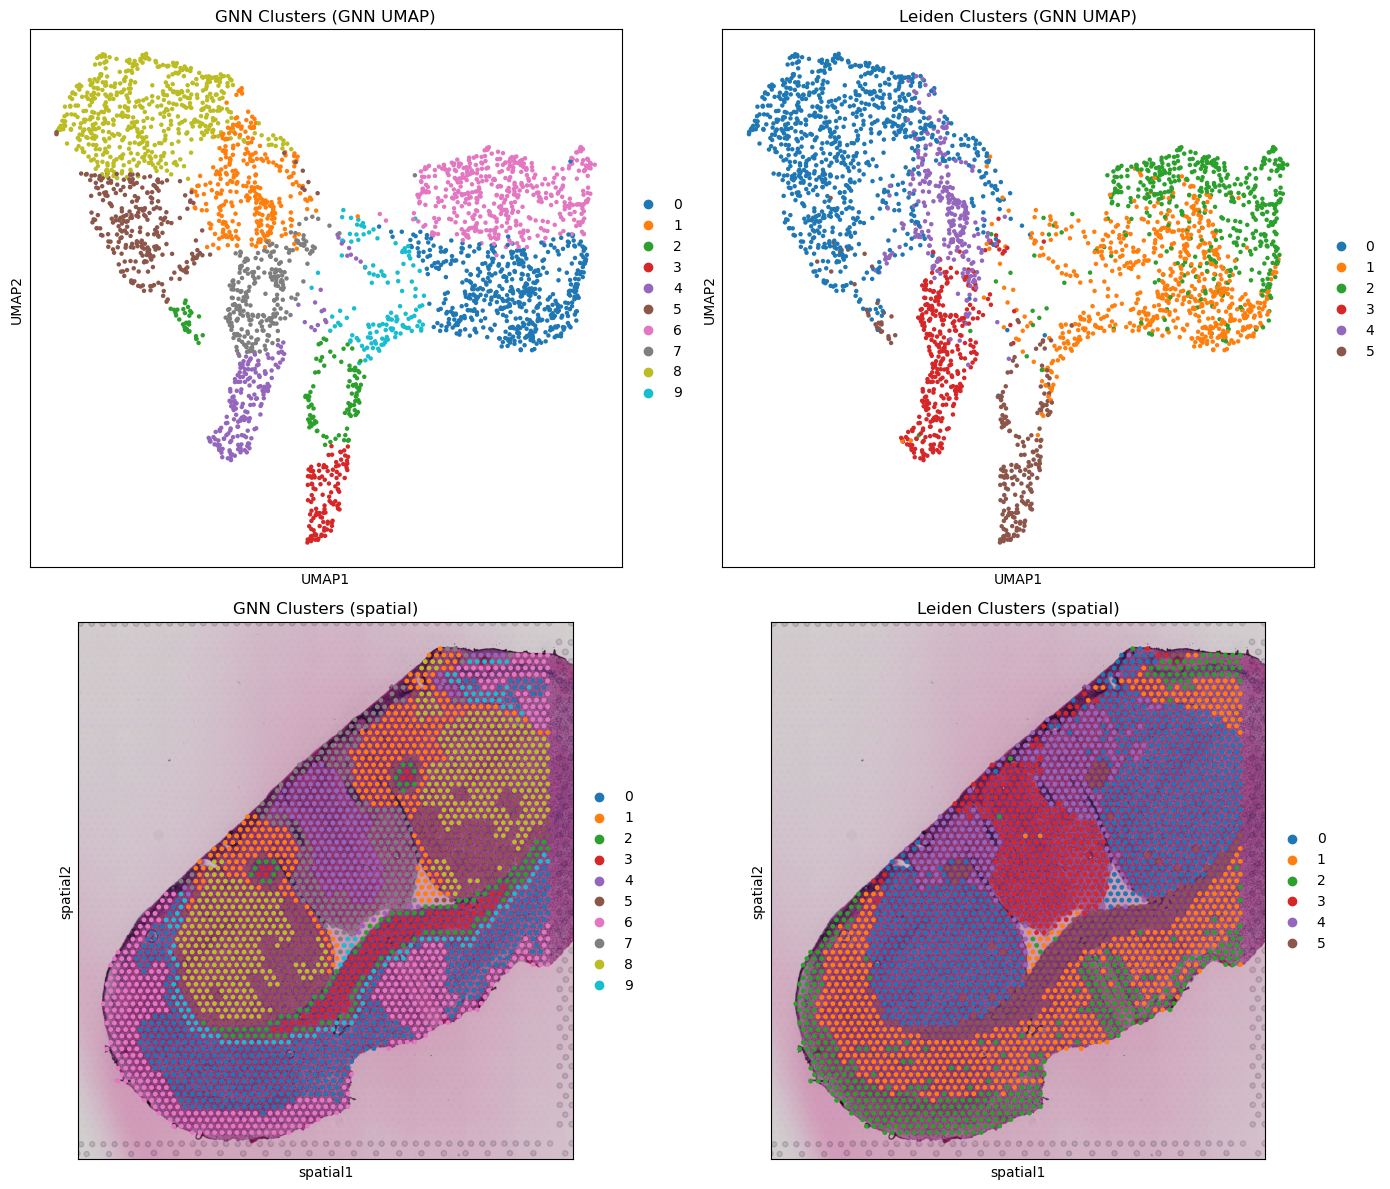

In [8]:
# Compare GNN clusters with Leiden on HVG expression space
sc.pp.neighbors(adata, use_rep='X', key_added='expr_neighbors')
sc.tl.leiden(adata, resolution=0.5, neighbors_key='expr_neighbors', key_added='leiden')

# Build GNN-embedding UMAP for visualization
sc.pp.neighbors(adata, use_rep='X_gnn', key_added='gnn_neighbors')
sc.tl.umap(adata, neighbors_key='gnn_neighbors')

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
sc.pl.umap(adata, color='gnn_cluster', ax=axes[0, 0], show=False, title='GNN Clusters (GNN UMAP)')
sc.pl.umap(adata, color='leiden', ax=axes[0, 1], show=False, title='Leiden Clusters (GNN UMAP)')
sc.pl.spatial(adata, color='gnn_cluster', ax=axes[1, 0], show=False, title='GNN Clusters (spatial)')
sc.pl.spatial(adata, color='leiden', ax=axes[1, 1], show=False, title='Leiden Clusters (spatial)')
plt.tight_layout()
plt.show()

In [9]:
ari = adjusted_rand_score(adata.obs['leiden'], adata.obs['gnn_cluster'])
nmi = normalized_mutual_info_score(adata.obs['leiden'], adata.obs['gnn_cluster'])
print(f'GNN vs. Leiden agreement:')
print(f'  Adjusted Rand Index (ARI):         {ari:.3f}')
print(f'  Normalized Mutual Info (NMI):      {nmi:.3f}')

GNN vs. Leiden agreement:
  Adjusted Rand Index (ARI):         0.474
  Normalized Mutual Info (NMI):      0.619


## Next Steps

This baseline gives you a working graph autoencoder on one Visium sample. To extend it:

1. **Better architectures**: Try GATConv (attention), GraphSAGE, or deeper models with residual connections.
2. **Better losses**: Add contrastive learning (InfoNCE) to pull spatial neighbors closer and push non-neighbors apart.
3. **Multi-sample analysis**: Run across all samples in a dataset and compare clusters between diseased/control tissue. For the bleomycin lung dataset, this is a natural next step (6 bleo + 2 control).
4. **Sample-level classification**: Aggregate spot embeddings per sample (mean pooling, attention pooling, MIL) for sample-level disease classification. Use **leave-one-sample-out CV**!
5. **Apply to MSI**: The same approach can be applied to MSI data — nodes are pixels, features are m/z intensities.
6. **Cross-modal extension** (Direction B/C): Use the learned GNN embeddings as one input to a cross-modal model.
7. **Biological validation**: Do the GNN clusters correspond to known brain regions? For the PD dataset, do they capture the lesioned vs. intact hemisphere difference?

See `PROJECT_DESCRIPTION.md` for the full project directions and references.